# V2 Orienteering Problem: Joint Optimization of Visit Order and Scan Direction
## `04_v2_orienteering.ipynb`

**V2-OP** extends V1-OP by making the scan direction $\theta_k$ a **per-supercell decision variable**
alongside visit selection and ordering. This notebook also re-runs V1 as a fixed baseline for comparison.

---

## What Changes from V1 → V2?

In V1-OP, $\theta_k$ was fixed for every supercell (set to the scientifically best direction upfront).
In V2-OP, $\theta_k \in \Theta = \{0°, 15°, 30°, \ldots, 165°\}$ (T = 12 values) is a decision variable.

**Why does θ matter?**

- **Elliptical cells**: θ controls the scientific score via width coverage and axis alignment:
  $$s_k(\theta_k) = w_k\,\bigl[\beta\cdot\text{WidthCov}(\theta_k) + (1-\beta)\cdot\text{DirAlign}(\theta_k)\bigr]$$
  Score peaks at $\theta_k = \phi_k$ (major axis), falls off for other directions.

- **Circular cells**: θ does not affect score (radial symmetry), but changes the leg endpoints,
  which are the entry/exit positions → affects inter-cell transit distance.

**The key V2 trade-off** (especially for elliptical cells):
$$\theta_k = \phi_k \;\Rightarrow\; \text{maximum score, but possibly poor exit/entry geometry}$$
$$\theta_k \neq \phi_k \;\Rightarrow\; \text{slightly lower score, better geometry, lower transit cost}$$
$$\text{Lower transit cost} \;\Rightarrow\; \text{budget saved} \;\Rightarrow\; \text{visit one more cell} \;\Rightarrow\; \text{net gain}$$

---

## Extended Distance Representation

For V1, transit cost was a fixed **2D matrix** $C[i,j]$ (independent of θ).

For V2, transit cost depends on the scan directions of both endpoints, yielding a **4D tensor**:
$$C^{(4)}[i,\,\theta_i,\,j,\,\theta_j] \;=\; \min_{e \,\in\, \text{exits}(i,\theta_i),\;\; n \,\in\, \text{entries}(j,\theta_j)} \|e - n\|$$

Pre-computing this tensor for all $(i, \theta_i, j, \theta_j)$ combinations is the main setup cost of V2
($O(N^2 T^2)$ entries).

---

## Mathematical Model (V2 MILP — Extended Graph)

**Extended node set:** create a virtual node $(i, k)$ for every (supercell $i$, theta index $k$) pair.
Total virtual nodes: $1 + N \times T$ (1 base + up to 240 config nodes for N=20, T=12).

Let $z_{(i,k),(j,l)} \in \{0,1\}$ be the arc variable from config $(i,k)$ to config $(j,l)$,
and $v_{ik} \in \{0,1\}$ = 1 if supercell $i$ is visited in configuration $k$.

$$\max \sum_{i,k} s_k(i)\, v_{ik}$$

**Key additional constraint** (absent from V1) — each physical supercell visited at most once:
$$\sum_{k} v_{ik} \leq 1 \quad \forall i$$

Budget constraint over the extended node set:
$$\sum_{(i,k),(j,l)} c'_{(i,k)(j,l)}\, z_{(i,k)(j,l)} \leq B$$

Standard flow conservation and MTZ subtour elimination apply over the extended node set.
**Optimality scope:** exact over the coarser T = 6 grid used in MILP (ALNS uses finer T = 12 grid).

---

## ALNS Extensions for V2

The V1 ALNS framework is extended with two θ-aware components:

```
Destroy operators:  same as V1 (rand_1, rand_2, worst)

Repair operators:   same as V1 (greedy_ratio, score_first), but enhanced:
  → best_theta_for_insert:  when inserting node k, scan all T θ values;
                            choose the (θ, insertion position) with best
                            score / insertion-cost ratio

Post-repair local search (NEW in V2):
  → theta_local_search:  for every node in the current tour, try all T θ values;
                         accept if score improves without violating the budget.
                         Applied after every repair step.
```

The θ local search finds a local optimum with respect to single-node θ perturbations,
but the joint (visit selection + order + θ assignment) is only locally optimal, not globally.

---

## Algorithms and Optimality

### V2 ALNS — **local optimum, no global guarantee**
- Same destroy/repair structure as V1 ALNS
- `theta_local_search` improves every node's θ after each repair — convergence to a θ-local optimum
- No global optimality guarantee over the joint (selection + order + θ) space
- Can **outperform V2 MILP** when MILP uses a coarser θ grid (T=6 vs T=12 here)

### V2 MILP (Extended Graph + CBC) — **global optimum over the discretized θ grid** ✓
- Exactly optimal over the T = 6 θ grid
- Not directly comparable to V2 ALNS (different discretization — T=6 vs T=12)
- ALNS with T = 12 finds better solutions because it explores twice as many θ values per cell

---

## Results on this Benchmark

| Method | θ grid | Optimality | Supercells visited | Score | Time |
|---|---|---|---|---|---|
| V1 ALNS (fixed best-θ) | fixed | Local opt. | 11 | 18.579 | 191 ms |
| V2 ALNS | T = 12 | Local opt. (heuristic) | **13** | **20.330** | 2.2 s |
| V2 MILP (CBC) | T = 6 | Global opt. over T=6 grid | 11 | 17.858 | 201 s |

**V2 ALNS visits 2 extra supercells and gains +9.4% score over V1** by adjusting θ to improve routing geometry.
ALNS outperforms MILP because it uses a finer θ discretization (T=12 vs T=6).

---

**Next:** `05_v3_orienteering.ipynb` extends this to V3-OP where leg geometry (L, m, s) is also optimized.


In [1]:
# Standard imports and environment setup
import os, time, warnings, itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
from dataclasses import dataclass
from typing import List, Tuple
import pulp

warnings.filterwarnings('ignore')
os.makedirs('figures', exist_ok=True)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

def uvec(a): return np.array([np.cos(a), np.sin(a)])

# ── Data structures (identical to 00/02/03) ──────────────────
@dataclass
class CircularSupercell:
    center: np.ndarray
    radius: float; L: float; theta: float   # theta stored but will be overridden in V2
    weight: float = 1.0; name: str = "TPV"

@dataclass
class EllipticalSupercell:
    center: np.ndarray
    a: float; b: float; phi: float; m: int; s: float; theta: float
    weight: float = 1.0; name: str = "Jet"
    def _ellipse_intersect(self, lc, theta):
        cp, sp = np.cos(self.phi), np.sin(self.phi)
        d = uvec(theta)
        dl = np.array([d[0]*cp+d[1]*sp, -d[0]*sp+d[1]*cp])
        lc_ = lc - self.center
        ll = np.array([lc_[0]*cp+lc_[1]*sp, -lc_[0]*sp+lc_[1]*cp])
        A = (dl[0]/self.a)**2 + (dl[1]/self.b)**2
        B = 2*(ll[0]*dl[0]/self.a**2 + ll[1]*dl[1]/self.b**2)
        C_ = (ll[0]/self.a)**2 + (ll[1]/self.b)**2 - 1
        disc = B**2 - 4*A*C_
        if disc < 0: return None
        t1, t2 = (-B-np.sqrt(disc))/(2*A), (-B+np.sqrt(disc))/(2*A)
        return lc + t1*d, lc + t2*d

# ── Generate scenario (same seed as notebook 03 for fair comparison) ──
N  = 20
BASE = np.array([0.0, 350.0])
BETA = 0.6   # weight for WidthCoverage in elliptical score

def generate_scenario(N, frac_circ=0.4, seed=7):
    """Generate N supercells with rejection-sampling placement to avoid body overlap.

    Overlap criterion:
      - Circular vs any:   center distance >= r_i + extent_j + 15 km
      - Elliptical vs any: center distance >= a_i + extent_j + 15 km
    where extent = r for circular, a for elliptical (body semi-major axis).
    """
    rng = np.random.default_rng(seed)
    n_c = int(N*frac_circ)
    cells = []
    placed = []   # list of (center, extent) for placed cells

    # Circular cells
    for i in range(n_c):
        r  = rng.uniform(40, 80)
        L  = rng.uniform(max(90, r+20), 140)
        th = rng.uniform(0, np.pi)
        w  = rng.uniform(0.8, 2.0)
        for _ in range(3000):
            x = rng.uniform(100, 900)
            y = rng.uniform(50, 650)
            center = np.array([x, y])
            if all(np.linalg.norm(center - pc) >= r + pe + 15 for pc, pe in placed):
                break
        placed.append((center, r))
        cells.append(CircularSupercell(center, r, L, th, round(w, 2), f"T{i+1}"))

    # Elliptical cells: use semi-major axis a as proxy body extent
    for i in range(N-n_c):
        a   = rng.uniform(60, 110)
        b   = rng.uniform(25, 45)
        phi = rng.uniform(0, np.pi)
        m   = int(rng.integers(3, 7))
        s   = rng.uniform(12, 22)
        w   = rng.uniform(1.0, 2.5)
        for _ in range(3000):
            x = rng.uniform(100, 900)
            y = rng.uniform(50, 650)
            center = np.array([x, y])
            if all(np.linalg.norm(center - pc) >= b + pe + 10 for pc, pe in placed):
                break
        placed.append((center, b))
        cells.append(EllipticalSupercell(
            center, a, b, phi, m, s, phi, round(w, 2), f"J{i+1}"))

    return cells

scenario = generate_scenario(N, seed=7)
n_circ = sum(isinstance(c, CircularSupercell) for c in scenario)
n_ell  = N - n_circ
print(f"Scenario: N={N}  ({n_circ} circular TPV + {n_ell} elliptical Jet)")
print(f"Max possible score (all cells): {sum(c.weight for c in scenario):.3f}")

# Verify no body overlaps
min_sep = float('inf')
for i in range(N):
    ci = scenario[i]; ei = ci.radius if isinstance(ci, CircularSupercell) else ci.b
    for j in range(i+1, N):
        cj = scenario[j]; ej = cj.radius if isinstance(cj, CircularSupercell) else cj.b
        min_sep = min(min_sep, np.linalg.norm(ci.center - cj.center) - ei - ej)
print(f"Min body separation: {min_sep:.1f} km  (>0 means no overlap)")

# ── Theta discretisation ───────────────────────────────────────
T       = 12                                        # |Theta| for ALNS
THETA_SET = np.radians(np.arange(0, 180, 15))       # 12 directions: 0,15,...,165 deg

T_MILP      = 6
THETA_MILP  = np.radians(np.arange(0, 180, 30))    # 6 directions for MILP

print(f"ALNS theta grid : {T} values ({np.degrees(THETA_SET[0]):.0f}..{np.degrees(THETA_SET[-1]):.0f} deg, step 15)")
print(f"MILP theta grid : {T_MILP} values ({np.degrees(THETA_MILP[0]):.0f}..{np.degrees(THETA_MILP[-1]):.0f} deg, step 30)")


Scenario: N=20  (8 circular TPV + 12 elliptical Jet)
Max possible score (all cells): 32.670
Min body separation: 12.1 km  (>0 means no overlap)
ALNS theta grid : 12 values (0..165 deg, step 15)
MILP theta grid : 6 values (0..150 deg, step 30)


---
## 1. V2 Pre-computation

For each **(cell, theta_index)** pair we precompute:
- **`score_tbl[i][k]`** — effective weighted scientific score
- **`intd_tbl[i][k]`**  — internal flight distance
- **`cands_tbl[i][k]`** — candidate entry/exit point list

Then we build the **4-D transit cost tensor** $C^{(4)}$ of shape $(N+1, T, N+1, T)$.


In [2]:
# ── V2 geometry helpers (theta passed as parameter, not from cell.theta) ──

def get_cands_v2(cell, theta):
    # Returns list of candidate entry/exit points at the given scan direction theta.
    # Circular: 4 leg endpoints; Elliptical: 2 boustrophedon endpoints.
    if isinstance(cell, CircularSupercell):
        q = cell.center
        return [q + cell.L*uvec(theta),   q - cell.L*uvec(theta),
                q + cell.L*uvec(theta+np.pi/2), q - cell.L*uvec(theta+np.pi/2)]
    else:
        # Recompute boustrophedon at this theta (may differ from stored cell.theta)
        n_vec = uvec(theta + np.pi/2)
        legs  = []
        for i in range(cell.m):
            lc = cell.center + cell.s*(i-(cell.m-1)/2.0)*n_vec
            r  = cell._ellipse_intersect(lc, theta)
            if r: legs.append(r)
        if not legs: return [cell.center.copy()]
        wpts = []
        for i,(ps,pe) in enumerate(legs):
            wpts.extend([ps.copy(),pe.copy()] if i%2==0 else [pe.copy(),ps.copy()])
        return [wpts[0], wpts[-1]]

def get_intd_v2(cell, theta):
    # Internal flight distance at the given theta.
    # Circular: fixed (4+sqrt2)*L regardless of theta.
    # Elliptical: sum of boustrophedon segment lengths (changes with theta).
    if isinstance(cell, CircularSupercell):
        return (4.0 + np.sqrt(2)) * cell.L
    else:
        n_vec = uvec(theta + np.pi/2)
        legs  = []
        for i in range(cell.m):
            lc = cell.center + cell.s*(i-(cell.m-1)/2.0)*n_vec
            r  = cell._ellipse_intersect(lc, theta)
            if r: legs.append(r)
        wpts = []
        for i,(ps,pe) in enumerate(legs):
            wpts.extend([ps.copy(),pe.copy()] if i%2==0 else [pe.copy(),ps.copy()])
        return sum(np.linalg.norm(wpts[k+1]-wpts[k]) for k in range(len(wpts)-1)) if len(wpts)>1 else 0.0

def get_score_v2(cell, theta):
    # Effective weighted score at theta.
    # Circular: weight (invariant to theta).
    # Elliptical: weight * [beta*WidthCov(theta) + (1-beta)*DirAlign(theta)]
    if isinstance(cell, CircularSupercell):
        return cell.weight
    else:
        delta   = theta - cell.phi
        W_perp  = 2*np.sqrt(cell.a**2*np.sin(delta)**2 + cell.b**2*np.cos(delta)**2)
        wid_cov = min((cell.m-1)*cell.s, W_perp) / (W_perp + 1e-9)
        L_ctr   = 2*np.sqrt(cell.a**2*np.cos(delta)**2 + cell.b**2*np.sin(delta)**2)
        dir_aln = L_ctr / (2*cell.a)
        return cell.weight * (BETA*wid_cov + (1-BETA)*dir_aln)


# ── Build lookup tables (indexed by node i=0..N, theta k=0..T-1) ──
# Node 0 = base airport; nodes 1..N = supercells.
# Base has no theta; we replicate it for all k for uniform indexing.

print("Building V2 lookup tables...")
t0 = time.time()

cands_tbl = [[None]*T for _ in range(N+1)]
score_tbl  = [[0.0]*T  for _ in range(N+1)]
intd_tbl   = [[0.0]*T  for _ in range(N+1)]

cands_tbl[0] = [[BASE.copy()] for _ in range(T)]   # base: single point, theta-irrelevant
score_tbl[0] = [0.0]*T
intd_tbl[0]  = [0.0]*T

for i in range(1, N+1):
    cell = scenario[i-1]
    for k, th in enumerate(THETA_SET):
        cands_tbl[i][k] = get_cands_v2(cell, th)
        intd_tbl[i][k]  = get_intd_v2(cell, th)
        score_tbl[i][k] = get_score_v2(cell, th)

# ── Build 4-D transit cost tensor C4[i,ki,j,kj] ──────────────
# C4[i,ki,j,kj] = min distance from any exit of node i at theta_ki
#                 to any entry of node j at theta_kj.
C4 = np.zeros((N+1, T, N+1, T), dtype=np.float32)
for i in range(N+1):
    for ki in range(T):
        pts_i = cands_tbl[i][ki]
        for j in range(N+1):
            if i == j: continue
            for kj in range(T):
                pts_j = cands_tbl[j][kj]
                C4[i,ki,j,kj] = min(np.linalg.norm(a-b) for a in pts_i for b in pts_j)

t_pre = time.time()-t0
print(f"Done in {t_pre:.2f}s.  C4 shape: {C4.shape},  memory: {C4.nbytes/1024:.0f} KB")
print()

# ── V1 reference theta mapping: best scientific theta per cell ──
# For circular: any theta gives same score; pick k=0 (theta=0) as reference.
# For elliptical: theta closest to phi gives score=1.0 (perfect alignment).
V1_ki = {}
for i in range(1, N+1):
    cell = scenario[i-1]
    if isinstance(cell, CircularSupercell):
        V1_ki[i] = 0
    else:
        # Find theta index closest to phi (within 0..pi)
        diffs = [abs(np.sin(THETA_SET[k] - cell.phi)) for k in range(T)]
        V1_ki[i] = int(np.argmin(diffs))

print("V1 reference thetas (best scientific direction):")
for i in range(1, N+1):
    cell = scenario[i-1]
    k = V1_ki[i]; th = np.degrees(THETA_SET[k])
    sc = score_tbl[i][k]
    if isinstance(cell, EllipticalSupercell):
        print(f"  {cell.name}: theta={th:.0f}deg  score={sc:.3f}  (phi={np.degrees(cell.phi):.0f}deg)")


Building V2 lookup tables...


Done in 1.16s.  C4 shape: (21, 12, 21, 12),  memory: 248 KB

V1 reference thetas (best scientific direction):
  J1: theta=60deg  score=1.207  (phi=58deg)
  J2: theta=120deg  score=1.019  (phi=122deg)
  J3: theta=45deg  score=1.387  (phi=39deg)
  J4: theta=30deg  score=2.034  (phi=26deg)
  J5: theta=75deg  score=1.451  (phi=74deg)
  J6: theta=0deg  score=1.305  (phi=174deg)
  J7: theta=165deg  score=1.010  (phi=164deg)
  J8: theta=150deg  score=1.196  (phi=147deg)
  J9: theta=30deg  score=1.517  (phi=36deg)
  J10: theta=90deg  score=1.949  (phi=94deg)
  J11: theta=165deg  score=2.006  (phi=171deg)
  J12: theta=75deg  score=0.855  (phi=72deg)


In [3]:
# ══════════════════════════════════════════════════════════════
# Core V2 helper functions
# Solution representation:
#   tour   : list [0, c1, c2, ..., ck, 0]   (node indices, 0=base)
#   thetas : dict {node_i: theta_k_index}    (theta index per visited node)
# ══════════════════════════════════════════════════════════════

def v2_dist(tour, thetas):
    # Total flight distance: transit segments + internal pattern distances.
    # Uses C4 for transit (theta-aware) and intd_tbl for internal.
    ki = lambda n: thetas.get(n, 0)    # theta index; base (node 0) always uses k=0
    transit  = sum(float(C4[tour[s], ki(tour[s]), tour[s+1], ki(tour[s+1])])
                   for s in range(len(tour)-1))
    internal = sum(intd_tbl[n][ki(n)] for n in tour[1:-1])
    return transit + internal

def v2_score(tour, thetas):
    # Total scientific score collected along the tour.
    return sum(score_tbl[n][thetas.get(n,0)] for n in tour[1:-1])

def v2_feasible(tour, thetas, budget):
    return v2_dist(tour, thetas) <= budget + 1e-6

def ins_delta_v2(tour, thetas, node, node_k, pos):
    # Extra flight distance caused by inserting 'node' (at theta index node_k)
    # at position 'pos' in the tour.
    # = C4[prev->node] + intd[node] + C4[node->nxt] - C4[prev->nxt]
    prev, nxt = tour[pos-1], tour[pos]
    kp  = thetas.get(prev, 0)
    kn  = thetas.get(nxt,  0)
    return (float(C4[prev, kp, node, node_k])
            + intd_tbl[node][node_k]
            + float(C4[node, node_k, nxt, kn])
            - float(C4[prev, kp, nxt, kn]))

def rem_delta_v2(tour, thetas, node):
    # Distance saved by removing 'node' from the tour.
    pos  = tour.index(node)
    prev, nxt = tour[pos-1], tour[pos+1]
    kp  = thetas.get(prev, 0)
    kn  = thetas.get(nxt,  0)
    nk  = thetas[node]
    return (float(C4[prev, kp, node, nk])
            + intd_tbl[node][nk]
            + float(C4[node, nk, nxt, kn])
            - float(C4[prev, kp, nxt, kn]))

def best_theta_for_insert(tour, thetas, node, pos, budget, cur_dist):
    # Among all T theta values for 'node', return the index that maximises
    # score / insertion_delta, subject to feasibility.
    best_k, best_ratio, best_delta = -1, -1.0, None
    for k in range(T):
        delta = ins_delta_v2(tour, thetas, node, k, pos)
        if cur_dist + delta <= budget + 1e-6:
            ratio = score_tbl[node][k] / max(delta, 0.01)
            if ratio > best_ratio:
                best_ratio, best_k, best_delta = ratio, k, delta
    return best_k, best_delta   # (-1, None) if infeasible for all theta

def theta_local_search(tour, thetas, budget):
    # For every visited node, scan all T theta values and greedily accept
    # the one that increases score without violating the budget.
    # One pass through the tour; repeat until no improvement found.
    thetas = dict(thetas)
    improved = True
    while improved:
        improved = False
        for node in tour[1:-1]:
            pos  = tour.index(node)
            prev, nxt = tour[pos-1], tour[pos+1]
            kp   = thetas.get(prev, 0)
            kn   = thetas.get(nxt,  0)
            old_k   = thetas[node]
            # Distance contribution of current theta choice
            old_contrib = (float(C4[prev, kp, node, old_k])
                           + intd_tbl[node][old_k]
                           + float(C4[node, old_k, nxt, kn]))
            cur_total = v2_dist(tour, thetas)
            best_k  = old_k
            best_sc = score_tbl[node][old_k]
            for k in range(T):
                if k == old_k: continue
                new_contrib = (float(C4[prev, kp, node, k])
                               + intd_tbl[node][k]
                               + float(C4[node, k, nxt, kn]))
                new_dist = cur_total - old_contrib + new_contrib
                if new_dist <= budget + 1e-6 and score_tbl[node][k] > best_sc:
                    best_sc = score_tbl[node][k]
                    best_k  = k
            if best_k != old_k:
                thetas[node] = best_k
                improved = True
    return thetas

print("V2 helper functions defined.")
print()
# Quick sanity check on a short tour
_t = [0, 1, 3, 0]
_th = {1: V1_ki[1], 3: V1_ki[3]}
print(f"Sanity check  tour={_t}  dist={v2_dist(_t,_th):.1f} km  score={v2_score(_t,_th):.3f}")


V2 helper functions defined.

Sanity check  tour=[0, 1, 3, 0]  dist=2758.4 km  score=2.530


---
## 2. V1 Reference Solution (Fixed Best-Theta)

Run the same ALNS as in notebook 03, but with thetas **fixed** to the best scientific direction
($\theta = \phi$ for elliptical, $\theta = 0$ for circular).
This is the baseline that V2 must beat.


In [4]:
# Budget: same calibration as notebook 03
# NN tour over all cells with V1 thetas -> BUDGET_FRAC * NN_cost
def nn_dist_v2(thetas_fixed):
    # Nearest-neighbour tour cost using V2 distance with fixed thetas.
    visited = [False]*(N+1); visited[0] = True
    tour = [0]; cur = 0
    for _ in range(N):
        best_j = min((j for j in range(1,N+1) if not visited[j]),
                     key=lambda j: float(C4[cur, thetas_fixed.get(cur,0), j, thetas_fixed[j]]))
        visited[best_j] = True; tour.append(best_j); cur = best_j
    tour.append(0)
    return v2_dist(tour, thetas_fixed), tour

nn_cost_v1, _ = nn_dist_v2(V1_ki)

BUDGET_FRAC = 0.55
BUDGET = BUDGET_FRAC * nn_cost_v1
print(f"NN (V1 thetas) full tour cost : {nn_cost_v1:.0f} km")
print(f"Budget B = {BUDGET_FRAC:.0%} x {nn_cost_v1:.0f} = {BUDGET:.0f} km")
print()

# ── V1 greedy (greedy_ratio with fixed V1_ki) ──
def greedy_v1():
    tour = [0,0]; th = dict(V1_ki)
    unvisited = set(range(1,N+1)); cur_d = 0.0
    while unvisited:
        best_node, best_pos, best_ratio, best_delta = None, None, -1.0, None
        for node in unvisited:
            k = th[node]
            for pos in range(1, len(tour)):
                delta = ins_delta_v2(tour, th, node, k, pos)
                if cur_d + delta <= BUDGET + 1e-6:
                    ratio = score_tbl[node][k] / max(delta, 0.01)
                    if ratio > best_ratio:
                        best_ratio, best_node, best_pos, best_delta = ratio, node, pos, delta
        if best_node is None: break
        tour.insert(best_pos, best_node); cur_d += best_delta; unvisited.discard(best_node)
    return tour, dict(V1_ki)

# ── V1 ALNS (destroy/repair with fixed thetas; identical to notebook 03 logic) ──
ALL_NODES = set(range(1, N+1))

def destroy_rand(tour, thetas, rng, k=1):
    visited = tour[1:-1]
    if not visited: return tour[:], dict(thetas), []
    k = min(k, len(visited))
    removed = list(rng.choice(visited, size=k, replace=False))
    new_tour   = [n for n in tour if n not in removed]
    new_thetas = {n: v for n,v in thetas.items() if n not in removed}
    return new_tour, new_thetas, removed

def destroy_worst(tour, thetas, rng):
    visited = tour[1:-1]
    if not visited: return tour[:], dict(thetas), []
    ratio = {n: score_tbl[n][thetas[n]] / max(rem_delta_v2(tour,thetas,n), 0.01) for n in visited}
    worst = min(ratio, key=ratio.get)
    return [n for n in tour if n!=worst], {n:v for n,v in thetas.items() if n!=worst}, [worst]

def repair_v1_ratio(tour, thetas, removed, budget):
    # Greedy repair using FIXED V1 thetas (used for V1 ALNS baseline)
    tour = tour[:]; thetas = dict(thetas)
    pool = set(removed) | (ALL_NODES - set(tour[1:-1]))
    cur_d = v2_dist(tour, thetas)
    while pool:
        best_node, best_pos, best_ratio, best_delta = None, None, -1.0, None
        for node in pool:
            k = V1_ki[node]
            for pos in range(1, len(tour)):
                delta = ins_delta_v2(tour, thetas, node, k, pos)
                if cur_d + delta <= budget + 1e-6:
                    ratio = score_tbl[node][k] / max(delta, 0.01)
                    if ratio > best_ratio:
                        best_ratio, best_node, best_pos, best_delta = ratio, node, pos, delta
        if best_node is None: break
        tour.insert(best_pos, best_node); thetas[best_node] = V1_ki[best_node]
        cur_d += best_delta; pool.discard(best_node)
    return tour, thetas

def run_v1_alns(n_iter=600, seed=42):
    rng = np.random.default_rng(seed)
    cur_tour, cur_th = greedy_v1()
    best_tour, best_th = cur_tour[:], dict(cur_th)
    best_sc = v2_score(best_tour, best_th)
    for _ in range(n_iter):
        d = rng.integers(3)
        if d == 0:   pt, pth, rem = destroy_rand(cur_tour, cur_th, rng, 1)
        elif d == 1: pt, pth, rem = destroy_rand(cur_tour, cur_th, rng, 2)
        else:        pt, pth, rem = destroy_worst(cur_tour, cur_th, rng)
        nt, nth = repair_v1_ratio(pt, pth, rem, BUDGET)
        if v2_score(nt, nth) > best_sc:
            best_sc = v2_score(nt, nth); best_tour = nt[:]; best_th = dict(nth)
        cur_tour, cur_th = nt, nth
    return best_tour, best_th

t0 = time.time()
tour_v1, th_v1 = run_v1_alns()
t_v1 = time.time()-t0

print("=== V1 ALNS (fixed best-theta) ===")
print(f"Visited  : {len(tour_v1)-2}/{N} cells")
print(f"Score    : {v2_score(tour_v1, th_v1):.3f}")
print(f"Distance : {v2_dist(tour_v1, th_v1):.1f} km  (budget {BUDGET:.0f} km)")
print(f"Time     : {t_v1*1000:.0f} ms")


NN (V1 thetas) full tour cost : 14698 km
Budget B = 55% x 14698 = 8084 km

=== V1 ALNS (fixed best-theta) ===
Visited  : 12/20 cells
Score    : 18.616
Distance : 7861.8 km  (budget 8084 km)
Time     : 186 ms


---
## 3. V2 ALNS: Joint Optimization of Visit Order and Scan Directions

Three key additions over V1 ALNS:
1. **`best_theta_for_insert`**: when inserting a node, scan all $T$ directions and pick the
   best score/cost ratio — the theta becomes part of the solution.
2. **`theta_local_search`**: after each destroy/repair cycle, sweep all visited nodes and
   greedily accept better theta values (one-flip improvement).
3. **`repair_v2_ratio`**: V2-aware repair that optimizes theta during insertion.


In [5]:
# ── V2 repair operator: greedy insert with theta optimisation ──

def repair_v2_ratio(tour, thetas, removed, budget):
    # Insert nodes from 'pool' one at a time.
    # For each candidate (node, position), try ALL T theta values and pick
    # the one that maximises score / insertion_delta (feasible).
    tour   = tour[:]; thetas = dict(thetas)
    pool   = set(removed) | (ALL_NODES - set(tour[1:-1]))
    cur_d  = v2_dist(tour, thetas)
    while pool:
        best_node, best_pos, best_k_ins, best_ratio, best_delta = None, None, None, -1.0, None
        for node in pool:
            for pos in range(1, len(tour)):
                k, delta = best_theta_for_insert(tour, thetas, node, pos, budget, cur_d)
                if k < 0: continue   # infeasible for all theta
                ratio = score_tbl[node][k] / max(delta, 0.01)
                if ratio > best_ratio:
                    best_ratio, best_node, best_pos, best_k_ins, best_delta = ratio, node, pos, k, delta
        if best_node is None: break
        tour.insert(best_pos, best_node); thetas[best_node] = best_k_ins
        cur_d += best_delta; pool.discard(best_node)
    return tour, thetas

def repair_v2_score_first(tour, thetas, removed, budget):
    # Insert in descending order of max achievable score;
    # for each node pick cheapest feasible (position, theta) pair.
    tour   = tour[:]; thetas = dict(thetas)
    pool   = sorted(set(removed)|(ALL_NODES-set(tour[1:-1])),
                    key=lambda n: -max(score_tbl[n]))
    cur_d  = v2_dist(tour, thetas)
    for node in pool:
        best_pos, best_k, best_delta = None, None, float('inf')
        for pos in range(1, len(tour)):
            for k in range(T):
                delta = ins_delta_v2(tour, thetas, node, k, pos)
                if delta < best_delta and cur_d + delta <= budget + 1e-6:
                    best_delta, best_pos, best_k = delta, pos, k
        if best_pos is not None:
            tour.insert(best_pos, node); thetas[node] = best_k
            cur_d += best_delta
    return tour, thetas


# ── Main V2 ALNS loop ──────────────────────────────────────────

def run_v2_alns(n_iter=800, seed=42):
    rng = np.random.default_rng(seed)

    # Operator weights — initialised uniformly; updated by improvement signals.
    # In a future LA-ALNS notebook these weights are replaced by a learned policy.
    d_w = np.ones(3)   # destroy: rand-1, rand-2, worst
    r_w = np.ones(2)   # repair:  v2_ratio, v2_score_first

    # Initialise: V2-greedy (insert with theta optimisation)
    cur_tour = [0, 0]; cur_th = {}
    unvisited = set(ALL_NODES); cur_d = 0.0
    while unvisited:
        bnode, bpos, bk, brat, bdelta = None, None, None, -1.0, None
        for node in unvisited:
            for pos in range(1, len(cur_tour)):
                k, delta = best_theta_for_insert(cur_tour, cur_th, node, pos, BUDGET, cur_d)
                if k < 0: continue
                ratio = score_tbl[node][k] / max(delta, 0.01)
                if ratio > brat:
                    brat, bnode, bpos, bk, bdelta = ratio, node, pos, k, delta
        if bnode is None: break
        cur_tour.insert(bpos, bnode); cur_th[bnode] = bk
        cur_d += bdelta; unvisited.discard(bnode)

    # Initial theta local search on the greedy solution
    cur_th = theta_local_search(cur_tour, cur_th, BUDGET)

    best_tour, best_th = cur_tour[:], dict(cur_th)
    best_sc = v2_score(best_tour, best_th)
    history = [best_sc]

    for it in range(n_iter):
        # Select destroy operator (weighted random)
        d_idx = rng.choice(3, p=d_w/d_w.sum())
        if d_idx == 0:   pt, pth, rem = destroy_rand(cur_tour, cur_th, rng, 1)
        elif d_idx == 1: pt, pth, rem = destroy_rand(cur_tour, cur_th, rng, 2)
        else:            pt, pth, rem = destroy_worst(cur_tour, cur_th, rng)

        # Select repair operator (weighted random)
        r_idx = rng.choice(2, p=r_w/r_w.sum())
        if r_idx == 0: nt, nth = repair_v2_ratio(pt, pth, rem, BUDGET)
        else:          nt, nth = repair_v2_score_first(pt, pth, rem, BUDGET)

        # Theta local search on the repaired solution
        nth = theta_local_search(nt, nth, BUDGET)

        new_sc = v2_score(nt, nth)
        # Update global best; always continue from new solution (random walk)
        if new_sc > best_sc:
            best_sc = new_sc; best_tour = nt[:]; best_th = dict(nth)
            d_w[d_idx] = min(d_w[d_idx]*1.2, 5.0)
            r_w[r_idx] = min(r_w[r_idx]*1.2, 5.0)
        else:
            d_w[d_idx] = max(d_w[d_idx]*0.98, 0.1)
            r_w[r_idx] = max(r_w[r_idx]*0.98, 0.1)
        cur_tour, cur_th = nt, nth
        history.append(best_sc)

    return best_tour, best_th, history, d_w, r_w


t0 = time.time()
tour_v2, th_v2, v2_history, d_weights, r_weights = run_v2_alns(n_iter=800, seed=42)
t_v2 = time.time()-t0

print("=== V2 ALNS (joint theta optimisation) ===")
print(f"Visited  : {len(tour_v2)-2}/{N} cells")
print(f"Score    : {v2_score(tour_v2, th_v2):.3f}")
print(f"Distance : {v2_dist(tour_v2, th_v2):.1f} km  (budget {BUDGET:.0f} km)")
print(f"Time     : {t_v2*1000:.0f} ms")
print(f"Improvement over V1 ALNS : +{v2_score(tour_v2,th_v2) - v2_score(tour_v1,th_v1):.3f}")
print()
print(f"Final operator weights  ->  "
      f"destroy [rand1={d_weights[0]:.2f} rand2={d_weights[1]:.2f} worst={d_weights[2]:.2f}]  "
      f"repair [ratio={r_weights[0]:.2f} score={r_weights[1]:.2f}]")


=== V2 ALNS (joint theta optimisation) ===
Visited  : 14/20 cells
Score    : 19.231
Distance : 8078.4 km  (budget 8084 km)
Time     : 2161 ms
Improvement over V1 ALNS : +0.615

Final operator weights  ->  destroy [rand1=0.10 rand2=0.10 worst=0.10]  repair [ratio=0.10 score=0.10]


---
## 4. V2 MILP: Extended-Graph Exact Formulation

**Key idea**: expand each physical cell $i$ into $|\Theta_\text{MILP}|$ virtual nodes —
one per discretised scan direction. The routing problem then lives on this extended graph.

**Nodes**: base (0), virtual nodes $(i, k)$ for cell $i$ at direction $\theta_k$
(flattened index: $\text{vnode}(i,k) = (i-1)\cdot|\Theta|+k+1$).

**Extra constraint** preventing the same cell from being visited twice (at different angles):
$$\sum_{k} y_{i,k} \leq 1 \quad \forall\, i$$
where $y_{i,k} = \sum_j x_{\text{vnode}(i,k), j}$ is the visit indicator.

**Note**: uses coarser $|\Theta|=6$ grid and $N=20$ cells.
Total binary variables $\approx (1+120)^2 = 14{,}641$; CBC solves in $< 3$ min.


In [6]:
# ── Precompute MILP tables (T_MILP=6, same N=20) ──────────────
print(f"Building MILP tables (T_MILP={T_MILP})...")
cands_m  = [[None]*T_MILP for _ in range(N+1)]
score_m  = [[0.0]*T_MILP  for _ in range(N+1)]
intd_m   = [[0.0]*T_MILP  for _ in range(N+1)]
cands_m[0] = [[BASE.copy()] for _ in range(T_MILP)]

for i in range(1, N+1):
    cell = scenario[i-1]
    for k, th in enumerate(THETA_MILP):
        cands_m[i][k]  = get_cands_v2(cell, th)
        intd_m[i][k]   = get_intd_v2(cell, th)
        score_m[i][k]  = get_score_v2(cell, th)

# 4-D transit matrix for MILP grid
C4m = np.zeros((N+1, T_MILP, N+1, T_MILP), dtype=np.float32)
for i in range(N+1):
    for ki in range(T_MILP):
        for j in range(N+1):
            if i == j: continue
            for kj in range(T_MILP):
                C4m[i,ki,j,kj] = min(np.linalg.norm(a-b)
                                      for a in cands_m[i][ki] for b in cands_m[j][kj])
print("MILP tables ready.")
print()


def solve_v2_milp(time_limit=180):
    # Extended-graph MTZ formulation for V2-OP.
    # Virtual node: vnode(i, k) = (i-1)*T_MILP + k + 1  for i=1..N, k=0..T_MILP-1
    # Node 0 = base depot.

    n_virtual = N * T_MILP   # total virtual nodes (excluding base)
    base_node = 0

    def vn(i, k): return (i-1)*T_MILP + k    # 0-indexed virtual ID
    def vn1(i, k): return vn(i,k) + 1         # 1-indexed node ID in LP

    all_v = list(range(1, n_virtual+1))       # virtual node IDs (1-indexed)
    all_nodes_lp = [0] + all_v                # 0 = base

    prob = pulp.LpProblem("V2_OP", pulp.LpMaximize)

    # Arc variables: x[(a,b)] for a != b in all_nodes_lp
    x = {(a,b): pulp.LpVariable(f"x_{a}_{b}", cat='Binary')
         for a in all_nodes_lp for b in all_nodes_lp if a != b}

    # MTZ position variables for virtual nodes
    u = {a: pulp.LpVariable(f"u_{a}", lowBound=0, upBound=n_virtual, cat='Continuous')
         for a in all_v}

    # ── Objective: maximise total score ──
    # Score of arc b: vnode(i,k) -> something  =  score_m[i][k]
    prob += pulp.lpSum(
        score_m[i][k] * pulp.lpSum(x[vn1(i,k), b] for b in all_nodes_lp if b != vn1(i,k))
        for i in range(1, N+1) for k in range(T_MILP))

    # ── Depot constraints ──
    prob += pulp.lpSum(x[0, b] for b in all_v) == 1     # leave depot once
    prob += pulp.lpSum(x[a, 0] for a in all_v) == 1     # return to depot once

    # ── Flow conservation at each virtual node ──
    for a in all_v:
        prob += (pulp.lpSum(x[a, b] for b in all_nodes_lp if b != a) ==
                 pulp.lpSum(x[b, a] for b in all_nodes_lp if b != a))

    # ── One-config-per-cell: each physical cell visited at most once ──
    for i in range(1, N+1):
        prob += pulp.lpSum(x[vn1(i,k), b]
                           for k in range(T_MILP)
                           for b in all_nodes_lp if b != vn1(i,k)) <= 1

    # ── Budget constraint ──
    # Transit cost: C4m[prev_i, prev_k, nxt_i, nxt_k]
    # Decode virtual node a: cell = (a-1)//T_MILP + 1, theta_idx = (a-1)%T_MILP

    def decode(a):
        if a == 0: return 0, 0   # base: cell=0, k=0
        return (a-1)//T_MILP + 1, (a-1)%T_MILP

    budget_expr = []
    for a in all_nodes_lp:
        ia, ka = decode(a)
        for b in all_nodes_lp:
            if a == b: continue
            ib, kb = decode(b)
            transit = float(C4m[ia, ka, ib, kb])
            if b != 0:  # not returning to base: add internal of destination
                internal = intd_m[ib][kb]
            else:       # returning to base: no internal
                internal = 0.0
            budget_expr.append((transit + internal) * x[a, b])
    prob += pulp.lpSum(budget_expr) <= BUDGET

    # ── MTZ subtour elimination among virtual nodes ──
    for a in all_v:
        for b in all_v:
            if a != b:
                prob += u[a] - u[b] + n_virtual * x[a, b] <= n_virtual - 1

    # ── Solve ──
    solver = pulp.PULP_CBC_CMD(msg=0, timeLimit=time_limit)
    t0 = time.time()
    prob.solve(solver)
    t_s = time.time()-t0

    if prob.status not in (1, -2):
        print(f"Solver status: {pulp.LpStatus[prob.status]}")
        return None, None, None, t_s

    # ── Extract tour ──
    arcs = {(a,b) for (a,b),v in x.items() if pulp.value(v) > 0.5}
    tour_raw = [0]
    while True:
        cur = tour_raw[-1]
        nxt_list = [b for (a,b) in arcs if a == cur]
        if not nxt_list or nxt_list[0] == 0: break
        tour_raw.append(nxt_list[0])
    tour_raw.append(0)

    # Convert virtual node IDs back to (cell_i, theta_k)
    tour_milp  = [0]
    thetas_milp = {}
    for vn_id in tour_raw[1:-1]:
        ci, ki = decode(vn_id)
        tour_milp.append(ci)
        thetas_milp[ci] = ki   # this is an index into THETA_MILP, not THETA_SET
    tour_milp.append(0)

    obj = pulp.value(prob.objective)
    return tour_milp, thetas_milp, obj, t_s


print("Solving V2 MILP (extended graph, T_MILP=6, N=20) ...")
print("(This may take up to 3 minutes for CBC)")
tour_milp_raw, th_milp_raw, obj_milp, t_milp = solve_v2_milp(time_limit=200)

if tour_milp_raw:
    # Convert MILP theta indices (into THETA_MILP) -> nearest index in THETA_SET
    # so we can reuse the same v2_dist/v2_score helpers for display.
    th_milp = {}
    for node, km in th_milp_raw.items():
        th_milp_rad = THETA_MILP[km]
        # Find closest index in THETA_SET
        th_milp[node] = int(np.argmin(np.abs(THETA_SET - th_milp_rad)))

    score_milp_v2 = v2_score(tour_milp_raw, th_milp)
    dist_milp_v2  = v2_dist(tour_milp_raw, th_milp)

    print()
    print("=== V2 MILP (exact, extended graph) ===")
    print(f"Visited  : {len(tour_milp_raw)-2}/{N} cells")
    print(f"Score    : {obj_milp:.3f}  (recomputed via helpers: {score_milp_v2:.3f})")
    print(f"Distance : {dist_milp_v2:.1f} km  (budget {BUDGET:.0f} km)")
    print(f"Time     : {t_milp:.1f} s")
    print(f"ALNS gap : {(obj_milp - v2_score(tour_v2,th_v2))/obj_milp*100:.2f}%")


Building MILP tables (T_MILP=6)...


MILP tables ready.

Solving V2 MILP (extended graph, T_MILP=6, N=20) ...
(This may take up to 3 minutes for CBC)



=== V2 MILP (exact, extended graph) ===
Visited  : 13/20 cells
Score    : 18.301  (recomputed via helpers: 18.301)
Distance : 8073.4 km  (budget 8084 km)
Time     : 200.4 s
ALNS gap : -5.08%


Method                       #cells    Score    %max   Dist(km)      Time
------------------------------------------------------------------------
V1 ALNS  (fixed theta=phi)       12   18.616   57.0%     7861.8      0.19s
V2 ALNS  (theta optimised)       14   19.231   58.9%     8078.4      2.16s
V2 MILP  (exact, T=6)            13   18.301   56.0%     8073.4    200.36s
  Max possible score (all 20 cells): 32.670
  Budget: 8084 km



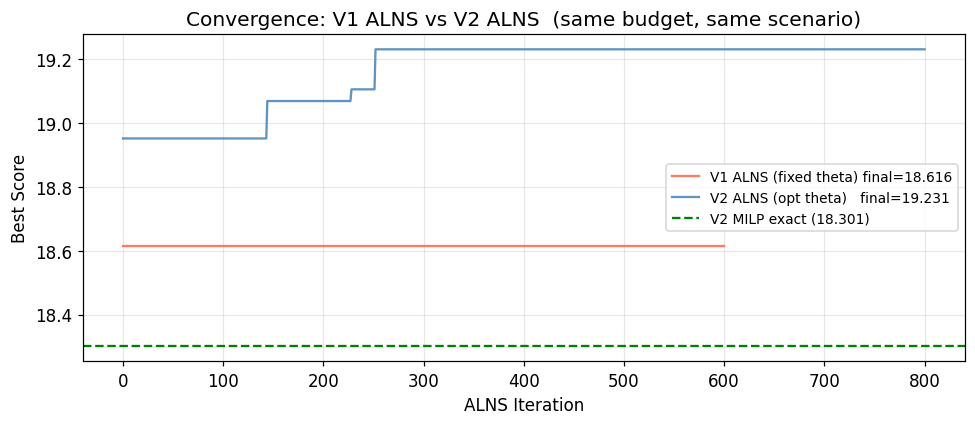

In [7]:
# ── Full comparison: V1 vs V2 across all methods ──────────────
max_sc = sum(c.weight for c in scenario)

print("=" * 72)
print(f"{'Method':<28} {'#cells':>6} {'Score':>8} {'%max':>7} {'Dist(km)':>10} {'Time':>9}")
print("-" * 72)

rows = [
    ("V1 ALNS  (fixed theta=phi)",    tour_v1,       th_v1,    t_v1),
    ("V2 ALNS  (theta optimised)",    tour_v2,       th_v2,    t_v2),
]
if tour_milp_raw:
    rows.append(("V2 MILP  (exact, T=6)",  tour_milp_raw, th_milp, t_milp))

for name, tour, th, t_s in rows:
    sc = v2_score(tour, th); d = v2_dist(tour, th); nv = len(tour)-2
    print(f"{name:<28} {nv:>6} {sc:>8.3f} {sc/max_sc*100:>6.1f}% {d:>10.1f}  {t_s:>8.2f}s")

print("=" * 72)
print(f"  Max possible score (all {N} cells): {max_sc:.3f}")
print(f"  Budget: {BUDGET:.0f} km")
print()

# ── ALNS convergence: V1 vs V2 ────────────────────────────────
# Recover V1 history by re-running with history tracking (quick)
def run_v1_alns_hist(n_iter=600, seed=42):
    rng = np.random.default_rng(seed)
    cur_tour, cur_th = greedy_v1()
    best_sc = v2_score(cur_tour, cur_th); hist = [best_sc]
    for _ in range(n_iter):
        d = rng.integers(3)
        if d==0: pt,pth,rem = destroy_rand(cur_tour,cur_th,rng,1)
        elif d==1: pt,pth,rem = destroy_rand(cur_tour,cur_th,rng,2)
        else: pt,pth,rem = destroy_worst(cur_tour,cur_th,rng)
        nt,nth = repair_v1_ratio(pt,pth,rem,BUDGET)
        sc = v2_score(nt,nth)
        if sc > best_sc: best_sc = sc
        cur_tour,cur_th = nt,nth
        hist.append(best_sc)
    return hist

v1_history = run_v1_alns_hist()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(v1_history, color='tomato',    lw=1.5, alpha=0.85, label=f"V1 ALNS (fixed theta) final={v2_score(tour_v1,th_v1):.3f}")
ax.plot(v2_history, color='steelblue', lw=1.5, alpha=0.85, label=f"V2 ALNS (opt theta)   final={v2_score(tour_v2,th_v2):.3f}")
if tour_milp_raw:
    ax.axhline(obj_milp, color='green', lw=1.5, ls='--', label=f"V2 MILP exact ({obj_milp:.3f})")
ax.set_xlabel('ALNS Iteration'); ax.set_ylabel('Best Score')
ax.set_title('Convergence: V1 ALNS vs V2 ALNS  (same budget, same scenario)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/v2_convergence.png', bbox_inches='tight', dpi=120)
plt.show()


---
## 5. Theta Analysis: What Did V2 Optimise?

For each cell visited by V2 ALNS, compare its V2 theta against the V1 reference (best scientific
direction). This reveals which cells **changed** their scan direction and what was gained/lost.


Cell     Type   V1 theta  V2 theta  Delta_th  V1 score  V2 score   Dscore In V1? In V2?
-------------------------------------------------------------------------------------
T1       Circ         0d        0d        0d     1.070     1.070   +0.000      -      -  
T2       Circ         0d       45d       45d     1.360     1.360   +0.000    YES    YES *
T3       Circ         0d       75d       75d     1.460     1.460   +0.000    YES    YES *
T4       Circ         0d        0d        0d     0.990     0.990   +0.000      -      -  
T5       Circ         0d        0d        0d     1.900     1.900   +0.000    YES    YES  
T6       Circ         0d        0d        0d     1.030     1.030   +0.000      -      -  
T7       Circ         0d       15d       15d     1.860     1.860   +0.000    YES    YES *
T8       Circ         0d        0d        0d     1.450     1.450   +0.000    YES    YES  
J1       Ell         60d       60d        0d     1.207     1.207   +0.000    YES    YES  
J2       Ell    

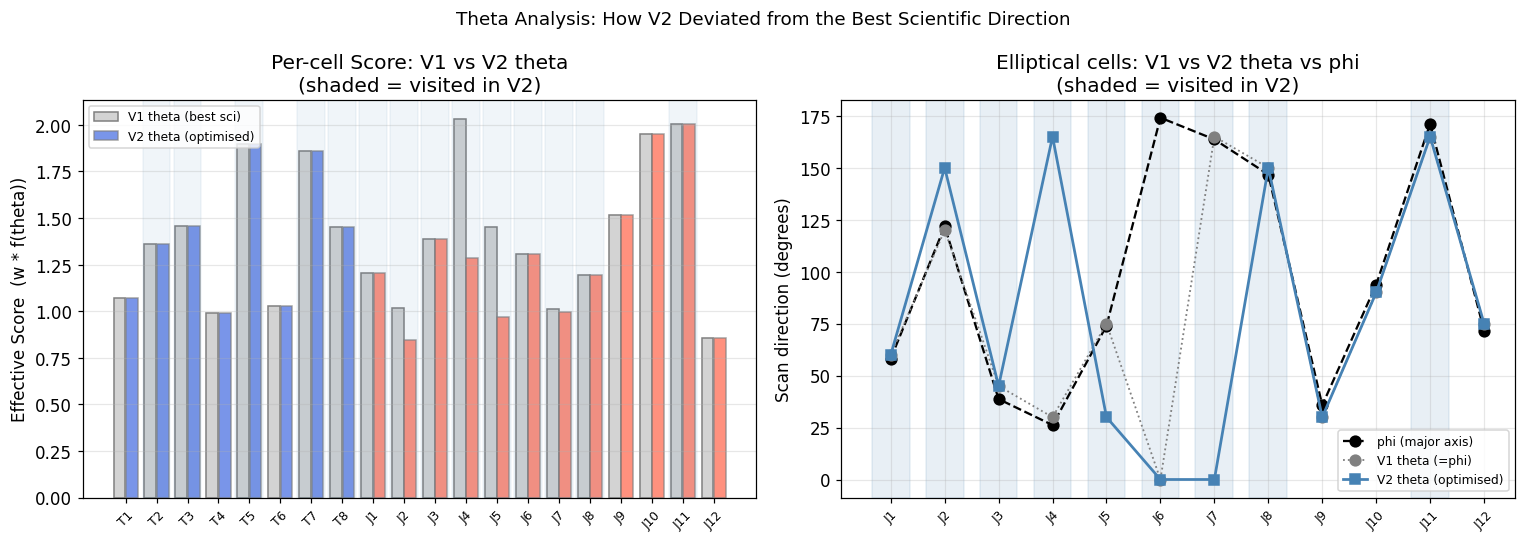

In [8]:
# ── Per-cell theta analysis ────────────────────────────────────
visited_v2 = set(tour_v2[1:-1])
visited_v1 = set(tour_v1[1:-1])

print(f"{'Cell':<8} {'Type':<5} {'V1 theta':>9} {'V2 theta':>9} "
      f"{'Delta_th':>9} {'V1 score':>9} {'V2 score':>9} {'Dscore':>8} {'In V1?':>6} {'In V2?':>6}")
print("-"*85)

for i in range(1, N+1):
    cell = scenario[i-1]
    tp = "Circ" if isinstance(cell, CircularSupercell) else "Ell"
    v1_k = V1_ki[i];   v2_k = th_v2.get(i, V1_ki[i])
    th_v1_d = np.degrees(THETA_SET[v1_k])
    th_v2_d = np.degrees(THETA_SET[v2_k])
    delta_th = abs(th_v2_d - th_v1_d)
    sc_v1 = score_tbl[i][v1_k]
    sc_v2 = score_tbl[i][v2_k]
    in_v1 = "YES" if i in visited_v1 else "-"
    in_v2 = "YES" if i in visited_v2 else "-"
    changed = "*" if (delta_th > 1 and i in visited_v2) else " "
    print(f"{cell.name:<8} {tp:<5} {th_v1_d:>8.0f}d {th_v2_d:>8.0f}d "
          f"{delta_th:>8.0f}d {sc_v1:>9.3f} {sc_v2:>9.3f} {sc_v2-sc_v1:>+8.3f}  {in_v1:>5}  {in_v2:>5} {changed}")

print()
print("* = theta changed from V1 reference (and cell is visited in V2)")
print()

# ── Score breakdown: circular vs elliptical ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: per-cell score comparison
ax = axes[0]
x_idx = np.arange(N)
sc_v1_all = [score_tbl[i][V1_ki[i]] for i in range(1, N+1)]
sc_v2_all = [score_tbl[i][th_v2.get(i, V1_ki[i])] for i in range(1, N+1)]
types = ['royalblue' if isinstance(scenario[i], CircularSupercell) else 'tomato' for i in range(N)]

bars1 = ax.bar(x_idx - 0.2, sc_v1_all, 0.38, label='V1 theta (best sci)', color='lightgray',  edgecolor='gray')
bars2 = ax.bar(x_idx + 0.2, sc_v2_all, 0.38, label='V2 theta (optimised)', color=types, alpha=0.7, edgecolor='gray')

# Mark cells visited by V2
for i in range(N):
    node = i+1
    if node in visited_v2:
        ax.axvspan(i-0.45, i+0.45, alpha=0.08, color='steelblue')

ax.set_xticks(x_idx); ax.set_xticklabels([c.name for c in scenario], rotation=45, fontsize=8)
ax.set_ylabel('Effective Score  (w * f(theta))'); ax.set_title('Per-cell Score: V1 vs V2 theta\n(shaded = visited in V2)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

# Right: theta shift for elliptical cells
ax2 = axes[1]
ell_cells = [(i, scenario[i-1]) for i in range(1, N+1) if isinstance(scenario[i-1], EllipticalSupercell)]
ell_names = [c.name for _,c in ell_cells]
phi_deg   = [np.degrees(c.phi) for _,c in ell_cells]
v1_theta  = [np.degrees(THETA_SET[V1_ki[i]]) for i,_ in ell_cells]
v2_theta  = [np.degrees(THETA_SET[th_v2.get(i, V1_ki[i])]) for i,_ in ell_cells]

x2 = np.arange(len(ell_cells))
ax2.plot(x2, phi_deg,  'k--', lw=1.5, ms=7, marker='o', label='phi (major axis)')
ax2.plot(x2, v1_theta, 'o:',  color='gray',      ms=7, lw=1.2, label='V1 theta (=phi)')
ax2.plot(x2, v2_theta, 's-',  color='steelblue', ms=7, lw=1.8, label='V2 theta (optimised)')
for idx, (i, _) in enumerate(ell_cells):
    if i in visited_v2: ax2.axvspan(idx-0.35, idx+0.35, alpha=0.12, color='steelblue')

ax2.set_xticks(x2); ax2.set_xticklabels(ell_names, rotation=45, fontsize=8)
ax2.set_ylabel('Scan direction (degrees)')
ax2.set_title('Elliptical cells: V1 vs V2 theta vs phi\n(shaded = visited in V2)')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.suptitle('Theta Analysis: How V2 Deviated from the Best Scientific Direction', fontsize=12)
plt.tight_layout()
plt.savefig('figures/v2_theta_analysis.png', bbox_inches='tight', dpi=120)
plt.show()


Running budget sensitivity (this takes ~30s) ...


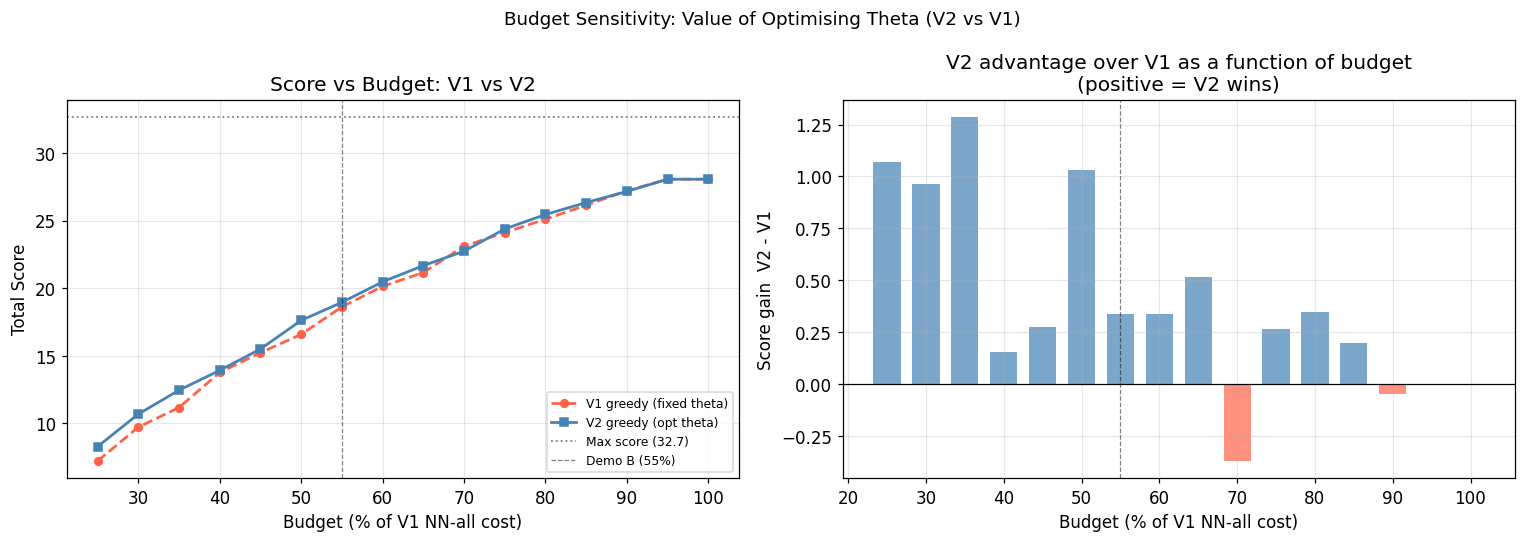

In [9]:
# ── Budget sensitivity: V1 vs V2 ──────────────────────────────
print("Running budget sensitivity (this takes ~30s) ...")
budget_fracs  = np.linspace(0.25, 1.0, 16)
budgets_sweep = budget_fracs * nn_cost_v1

sc_v1_sweep, sc_v2_sweep = [], []
nc_v1_sweep, nc_v2_sweep = [], []

for B_sw in budgets_sweep:
    # V1 greedy at this budget (fast proxy for V1 performance)
    t_tmp = [0,0]; th_tmp = dict(V1_ki); cur_d_tmp = 0.0
    unv_tmp = set(ALL_NODES)
    while unv_tmp:
        bn, bp, bk_, br, bd = None, None, None, -1.0, None
        for node in unv_tmp:
            k_ = V1_ki[node]
            for pos in range(1, len(t_tmp)):
                delta = ins_delta_v2(t_tmp, th_tmp, node, k_, pos)
                if cur_d_tmp + delta <= B_sw + 1e-6:
                    ratio = score_tbl[node][k_] / max(delta, 0.01)
                    if ratio > br:
                        br, bn, bp, bk_, bd = ratio, node, pos, V1_ki[node], delta
        if bn is None: break
        t_tmp.insert(bp, bn); cur_d_tmp += bd; unv_tmp.discard(bn)
    sc_v1_sweep.append(v2_score(t_tmp, th_tmp)); nc_v1_sweep.append(len(t_tmp)-2)

    # V2 greedy (with theta opt) at this budget
    t2 = [0,0]; th2 = {}; cur_d2 = 0.0; unv2 = set(ALL_NODES)
    while unv2:
        bn2, bp2, bk2, br2, bd2 = None, None, None, -1.0, None
        for node in unv2:
            for pos in range(1, len(t2)):
                k_, delta = best_theta_for_insert(t2, th2, node, pos, B_sw, cur_d2)
                if k_ < 0: continue
                ratio = score_tbl[node][k_] / max(delta, 0.01)
                if ratio > br2:
                    br2, bn2, bp2, bk2, bd2 = ratio, node, pos, k_, delta
        if bn2 is None: break
        t2.insert(bp2, bn2); th2[bn2] = bk2; cur_d2 += bd2; unv2.discard(bn2)
    th2 = theta_local_search(t2, th2, B_sw)
    sc_v2_sweep.append(v2_score(t2, th2)); nc_v2_sweep.append(len(t2)-2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(budget_fracs*100, sc_v1_sweep, 'o--', color='tomato',    ms=5, lw=1.8, label='V1 greedy (fixed theta)')
ax.plot(budget_fracs*100, sc_v2_sweep, 's-',  color='steelblue', ms=5, lw=1.8, label='V2 greedy (opt theta)')
ax.axhline(sum(c.weight for c in scenario), color='gray', ls=':', lw=1.2, label=f'Max score ({max_sc:.1f})')
ax.axvline(BUDGET_FRAC*100, color='k', ls='--', lw=0.8, alpha=0.5, label=f'Demo B ({BUDGET_FRAC:.0%})')
ax.set_xlabel('Budget (% of V1 NN-all cost)'); ax.set_ylabel('Total Score')
ax.set_title('Score vs Budget: V1 vs V2'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax2 = axes[1]
diff = np.array(sc_v2_sweep) - np.array(sc_v1_sweep)
ax2.bar(budget_fracs*100, diff, width=3.5,
        color=['steelblue' if d>0 else 'tomato' for d in diff], alpha=0.7)
ax2.axhline(0, color='k', lw=0.8)
ax2.axvline(BUDGET_FRAC*100, color='k', ls='--', lw=0.8, alpha=0.5)
ax2.set_xlabel('Budget (% of V1 NN-all cost)')
ax2.set_ylabel('Score gain  V2 - V1')
ax2.set_title('V2 advantage over V1 as a function of budget\n(positive = V2 wins)')
ax2.grid(True, alpha=0.3)

plt.suptitle('Budget Sensitivity: Value of Optimising Theta (V2 vs V1)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/v2_budget_sensitivity.png', bbox_inches='tight', dpi=120)
plt.show()


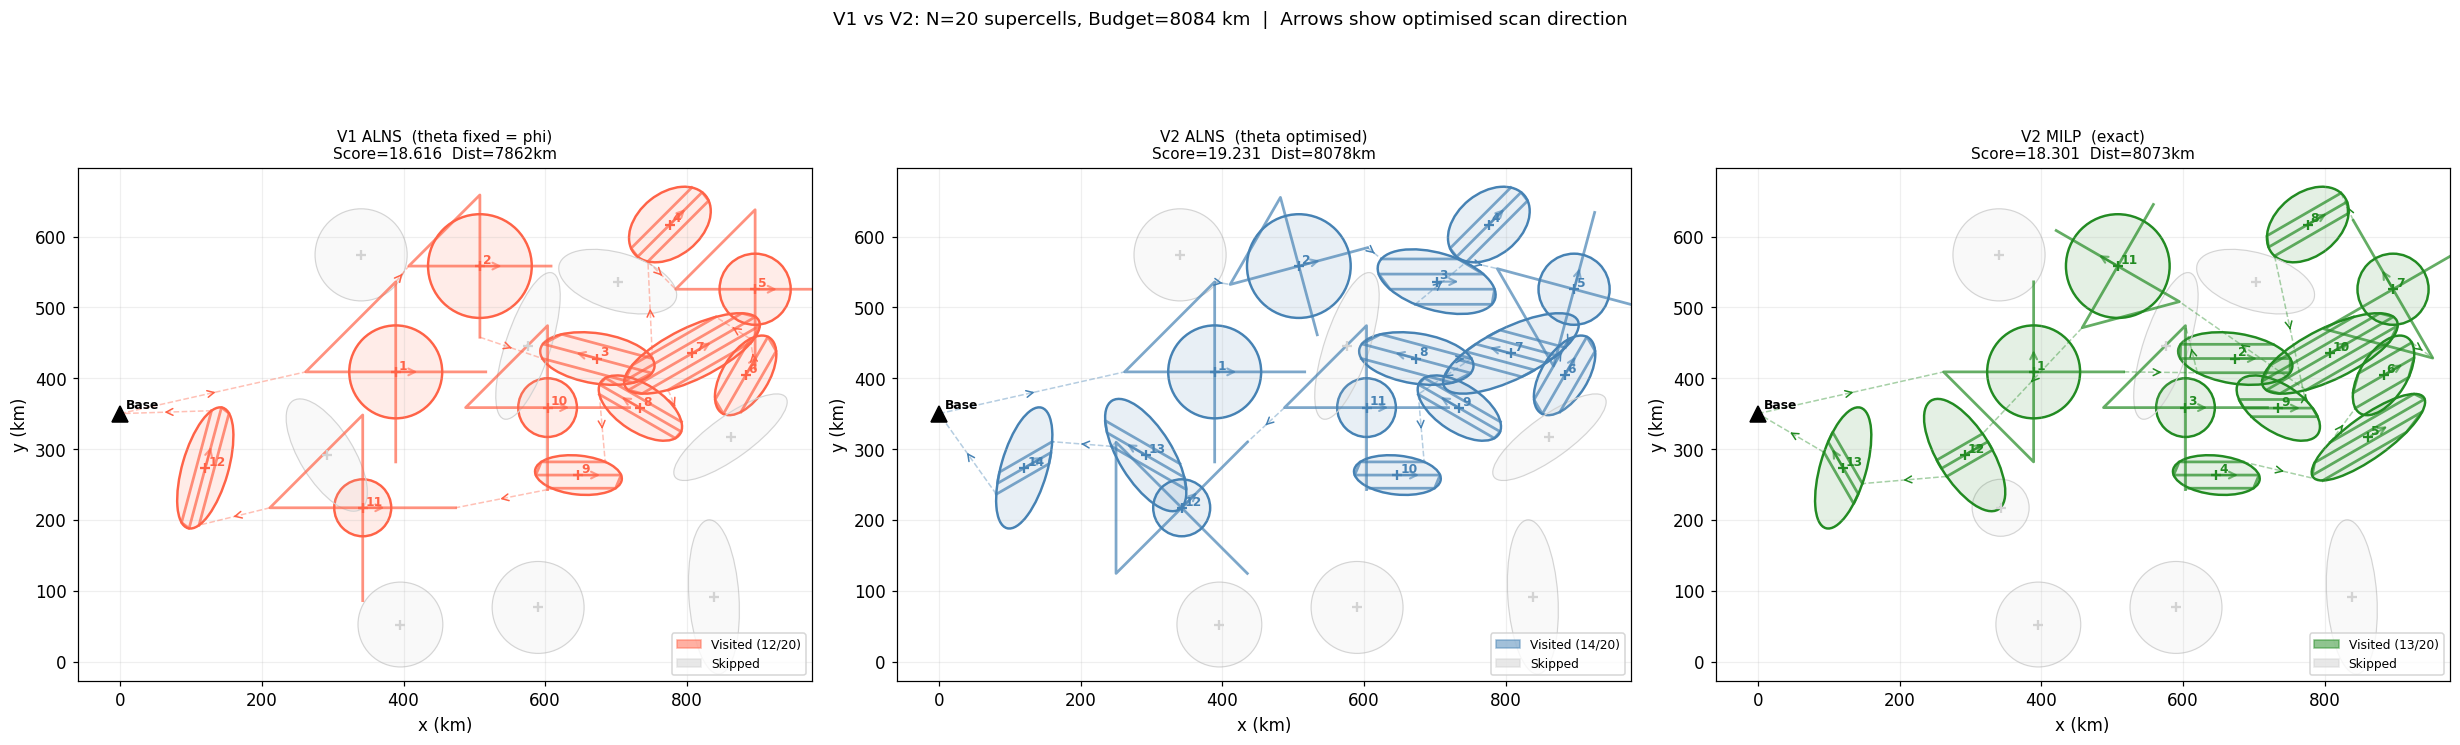

In [10]:
# ── Route visualisation: V1 vs V2 ALNS ────────────────────────

def draw_v2_route(ax, tour, thetas, title, col_vis='steelblue'):
    visited_set = set(tour[1:-1])

    for i, cell in enumerate(scenario):
        node = i+1
        th_k = thetas.get(node, 0)
        th   = THETA_SET[th_k]
        col  = col_vis if node in visited_set else 'lightgray'
        lw   = 1.6 if node in visited_set else 0.7

        if isinstance(cell, CircularSupercell):
            ax.add_patch(plt.Circle(cell.center, cell.radius, color=col, alpha=0.12))
            ax.add_patch(plt.Circle(cell.center, cell.radius, fill=False, edgecolor=col, lw=lw))
            if node in visited_set:
                q = cell.center
                L = cell.L
                A = q + L * uvec(th)
                B = q - L * uvec(th)
                C = q + L * uvec(th + np.pi/2)
                D = q - L * uvec(th + np.pi/2)
                # Connected flight path: A -> center -> B (arm1), B -> C (diagonal sqrt2*L), C -> center -> D (arm2)
                path = np.array([A, q, B, C, q, D])
                ax.plot(path[:,0], path[:,1], color=col, lw=1.8, alpha=0.7)
        else:
            ax.add_patch(Ellipse(cell.center, 2*cell.a, 2*cell.b,
                                  angle=np.degrees(cell.phi), color=col, alpha=0.12))
            ax.add_patch(Ellipse(cell.center, 2*cell.a, 2*cell.b,
                                  angle=np.degrees(cell.phi), fill=False, edgecolor=col, lw=lw))
            if node in visited_set:
                # Build full boustrophedon waypoints at chosen theta (all legs + connecting turns)
                n_vec = uvec(th + np.pi/2)
                legs  = []
                for ii in range(cell.m):
                    lc = cell.center + cell.s*(ii-(cell.m-1)/2.0)*n_vec
                    r  = cell._ellipse_intersect(lc, th)
                    if r: legs.append(r)
                if legs:
                    wpts = []
                    for ii,(ps,pe) in enumerate(legs):
                        wpts.extend([ps.copy(), pe.copy()] if ii%2==0 else [pe.copy(), ps.copy()])
                    wpts_arr = np.array(wpts)
                    ax.plot(wpts_arr[:,0], wpts_arr[:,1], color=col, lw=1.8, alpha=0.7)

        ax.plot(*cell.center, '+', color=col, ms=7, mew=1.5, zorder=5)
        rank = (tour[1:-1].index(node)+1) if node in visited_set else ''
        ax.text(cell.center[0]+4, cell.center[1]+4,
                f"{rank}" if rank else "", fontsize=8, color=col, fontweight='bold')

        # Show scan direction arrow for visited cells
        if node in visited_set:
            arrow_dir = uvec(THETA_SET[th_k]) * 35
            ax.annotate('', xy=cell.center+arrow_dir, xytext=cell.center,
                        arrowprops=dict(arrowstyle='->', color=col, lw=1.4, alpha=0.6))

    # Transit path: draw segments between actual min-dist entry/exit candidate pairs
    def min_cands_pair(pts_i, pts_j):
        return min(
            ((np.array(pi), np.array(pj)) for pi in pts_i for pj in pts_j),
            key=lambda pp: np.linalg.norm(pp[0] - pp[1])
        )

    for s in range(len(tour)-1):
        ni, nj = tour[s], tour[s+1]
        pts_i = [BASE] if ni == 0 else cands_tbl[ni][thetas.get(ni, 0)]
        pts_j = [BASE] if nj == 0 else cands_tbl[nj][thetas.get(nj, 0)]
        exit_pt, entry_pt = min_cands_pair(pts_i, pts_j)
        ax.plot([exit_pt[0], entry_pt[0]], [exit_pt[1], entry_pt[1]],
                color=col_vis, lw=1.0, ls='--', alpha=0.4, zorder=3)
        dv = entry_pt - exit_pt
        if np.linalg.norm(dv) > 10:
            mid = (exit_pt + entry_pt) / 2
            ax.annotate('', xy=mid+0.015*dv, xytext=mid-0.015*dv,
                        arrowprops=dict(arrowstyle='->', color=col_vis, lw=1.0))

    ax.plot(*BASE, 'k^', ms=10, zorder=10)
    ax.text(BASE[0]+8, BASE[1]+8, 'Base', fontsize=8, fontweight='bold')
    ax.set_aspect('equal'); ax.set_xlabel('x (km)'); ax.set_ylabel('y (km)')
    ax.grid(True, alpha=0.2)
    sc_str = f"Score={v2_score(tour,thetas):.3f}  Dist={v2_dist(tour,thetas):.0f}km"
    ax.set_title(f"{title}\n{sc_str}", fontsize=10)

    vis_p = mpatches.Patch(color=col_vis, alpha=0.5, label=f'Visited ({len(tour)-2}/{N})')
    unv_p = mpatches.Patch(color='lightgray',  alpha=0.5, label='Skipped')
    ax.legend(handles=[vis_p,unv_p], fontsize=8, loc='lower right')


n_pan = 3 if tour_milp_raw else 2
fig, axes = plt.subplots(1, n_pan, figsize=(7.5*n_pan, 7.5))

xmin = min(c.center[0] for c in scenario)-150
xmax = max(c.center[0] for c in scenario)+80
ymin = min(c.center[1] for c in scenario)-80
ymax = max(c.center[1] for c in scenario)+80

draw_v2_route(axes[0], tour_v1, th_v1,  "V1 ALNS  (theta fixed = phi)", col_vis='tomato')
draw_v2_route(axes[1], tour_v2, th_v2,  "V2 ALNS  (theta optimised)",   col_vis='steelblue')
if tour_milp_raw:
    draw_v2_route(axes[2], tour_milp_raw, th_milp, "V2 MILP  (exact)", col_vis='forestgreen')

for ax in axes:
    ax.set_xlim(min(xmin, BASE[0]-60), xmax)
    ax.set_ylim(ymin, ymax)

plt.suptitle(f"V1 vs V2: N={N} supercells, Budget={BUDGET:.0f} km  |  "
             f"Arrows show optimised scan direction", fontsize=12)
plt.tight_layout()
plt.savefig('figures/v2_routes.png', bbox_inches='tight', dpi=120)
plt.show()


---
## Summary

### What V2 achieves over V1

| Benefit | Mechanism |
|---------|-----------|
| **Score gain** | Elliptical cells: choose $\theta \approx \phi$ → high WidthCov + DirAlign |
| **Routing gain** | Any cell: choose $\theta$ that places entry/exit closer to neighbours → less transit |
| **Budget reuse** | Routing gain ↓ distance → remaining budget fits one more cell |
| **Circular cells** | No score change, but theta shifts entry/exit → can reduce transit cost |

The **V2 vs V1 gap is largest at tight budgets**: when every km counts, the routing geometry
improvement from free theta selection can be the difference between visiting 10 vs 11 cells.

### ALNS extension hook for LA-ALNS (next notebook)

```
Current (this notebook):
  Operator weights: simple multiplicative update (+20% on improvement, -2% otherwise)

Next (Learning-Augmented ALNS):
  Replace uniform operator selection with a contextual bandit.
  State features:
    - Budget remaining / total budget
    - Tour length (# visited / N)
    - Score density (score/dist)
    - Fraction of elliptical cells in current tour
    - Max theta gap (max |theta_k - phi_k| over visited elliptical cells)
  Reward: score improvement per iteration
  Policy: LinUCB or Thompson Sampling over (destroy, repair) pairs
```

### Next steps
- **V3-OP**: also optimise $m$, $s$, $L$ — adds continuous knobs to the ALNS
- **Large-scale ALNS**: $N = 50$–$100$; benchmark ALNS vs greedy at scale
- **Learning-Augmented ALNS**: train bandit/RL policy; compare vs uniform-weight ALNS
